In [353]:
import pandas as pd
df=pd.read_csv('all_kindle_review.csv')
df.head()

,Unnamed: 0.1,Unnamed: 0,asin,helpful,rating,reviewText,reviewTime,reviewerID,reviewerName,summary,unixReviewTime
0,0,11539,B0033UV8HI,"[8, 10]",3,"Jace Rankin may be short, but he's nothing to ...","09 2, 2010",A3HHXRELK8BHQG,Ridley,Entertaining But Average,1283385600
1,1,5957,B002HJV4DE,"[1, 1]",5,Great short read. I didn't want to put it dow...,"10 8, 2013",A2RGNZ0TRF578I,Holly Butler,Terrific menage scenes!,1381190400
2,2,9146,B002ZG96I4,"[0, 0]",3,I'll start by saying this is the first of four...,"04 11, 2014",A3S0H2HV6U1I7F,Merissa,Snapdragon Alley,1397174400
3,3,7038,B002QHWOEU,"[1, 3]",3,Aggie is Angela Lansbury who carries pocketboo...,"07 5, 2014",AC4OQW3GZ919J,Cleargrace,very light murder cozy,1404518400
4,4,1776,B001A06VJ8,"[0, 1]",4,I did not expect this type of book to be in li...,"12 31, 2012",A3C9V987IQHOQD,Rjostler,Book,1356912000


In [354]:
data=df[['reviewText','rating']]

In [355]:
data.head()

,reviewText,rating
0,"Jace Rankin may be short, but he's nothing to ...",3
1,Great short read. I didn't want to put it dow...,5
2,I'll start by saying this is the first of four...,3
3,Aggie is Angela Lansbury who carries pocketboo...,3
4,I did not expect this type of book to be in li...,4


In [356]:
data.shape

(12000, 2)

In [357]:
## Missing Values
data.isnull().sum()

,0
reviewText,0
rating,0


In [358]:
data['rating'].unique()

array([3, 5, 4, 2, 1])

In [359]:
data['rating'].value_counts()

,count
rating,
5,3000
4,3000
3,2000
2,2000
1,2000


###Preprocessing and Cleaning

In [360]:
#Positive review is 1 and Negative review is 0

In [361]:
data['rating']=data['rating'].apply(lambda x: 1 if x>=3 else 0)

/tmp/ipykernel_3935/1853798087.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['rating']=data['rating'].apply(lambda x: 1 if x>=3 else 0)


In [362]:
data['rating'].value_counts()

,count
rating,
1,8000
0,4000


In [363]:
## lower all the cases in reviewText
data['reviewText']=data['reviewText'].str.lower()

/tmp/ipykernel_3935/3527103823.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['reviewText']=data['reviewText'].str.lower()


In [364]:
data.head()

,reviewText,rating
0,"jace rankin may be short, but he's nothing to ...",1
1,great short read. i didn't want to put it dow...,1
2,i'll start by saying this is the first of four...,1
3,aggie is angela lansbury who carries pocketboo...,1
4,i did not expect this type of book to be in li...,1


In [365]:
import re
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [366]:
from bs4 import BeautifulSoup

In [367]:
## Checking special characters in a dataframe
special_char=data['reviewText'].str.contains(r'[^a-z0-9A-Z ]',regex=True)

In [368]:
special_char.value_counts()

,count
reviewText,
True,11914
False,86


In [369]:
data['special_char']=data['reviewText'].str.findall(r'[^a-z0-9A-Z ]')

/tmp/ipykernel_3935/562334587.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['special_char']=data['reviewText'].str.findall(r'[^a-z0-9A-Z ]')


In [370]:
data['special_char']

,special_char
0,"[,, ', ,, ., ', ,, ,, ', ., -, ,, ,, ., ,, ', ..."
1,"[., ', ., ., ., ., -, !, !, (, ), !]"
2,"[', ', &, #, ;, &, #, ;, ., ,, ,, ', ,, ., ', ..."
3,"[., ,, ., ,, ,, -, ., .]"
4,[]
...,...
11995,"[-, !, -]"
11996,"[., /, ,, ., ., ,, ., ., ., ., ., ,, ,, ., ,, ..."
11997,"[', ., ', ., ., ', ,, ', .]"
11998,"[,, ', ., ., .]"


In [371]:
## removing special characters --> re.sub(pattern, replacement, string)
data['reviewText']=data['reviewText'].apply(lambda x: re.sub('[^a-z0-9A-Z- ]+',' ',x))

/tmp/ipykernel_3935/279934442.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['reviewText']=data['reviewText'].apply(lambda x: re.sub('[^a-z0-9A-Z- ]+',' ',x))


In [372]:
data['reviewText']

,reviewText
0,jace rankin may be short but he s nothing to ...
1,great short read i didn t want to put it dow...
2,i ll start by saying this is the first of four...
3,aggie is angela lansbury who carries pocketboo...
4,i did not expect this type of book to be in li...
...,...
11995,valentine cupid is a vampire- jena and ian ano...
11996,i have read all seven books in this series ap...
11997,this book really just wasn t my cuppa the si...
11998,tried to use it to charge my kindle it didn t...


In [373]:
data.head()

,reviewText,rating,special_char
0,jace rankin may be short but he s nothing to ...,1,"[,, ', ,, ., ', ,, ,, ', ., -, ,, ,, ., ,, ', ..."
1,great short read i didn t want to put it dow...,1,"[., ', ., ., ., ., -, !, !, (, ), !]"
2,i ll start by saying this is the first of four...,1,"[', ', &, #, ;, &, #, ;, ., ,, ,, ', ,, ., ', ..."
3,aggie is angela lansbury who carries pocketboo...,1,"[., ,, ., ,, ,, -, ., .]"
4,i did not expect this type of book to be in li...,1,[]


In [374]:
##finding stopwords in a sentence
data['stop_words']=data['reviewText'].apply(lambda x: [y for y in x.split() if y.lower() in stopwords.words('english')])

/tmp/ipykernel_3935/1863822648.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['stop_words']=data['reviewText'].apply(lambda x: [y for y in x.split() if y.lower() in stopwords.words('english')])


In [375]:
data.head()

,reviewText,rating,special_char,stop_words
0,jace rankin may be short but he s nothing to ...,1,"[,, ', ,, ., ', ,, ,, ', ., -, ,, ,, ., ,, ', ...","[be, but, he, s, to, with, as, the, who, was, ..."
1,great short read i didn t want to put it dow...,1,"[., ', ., ., ., ., -, !, !, (, ), !]","[i, didn, t, to, it, down, so, i, it, all, in,..."
2,i ll start by saying this is the first of four...,1,"[', ', &, #, ;, &, #, ;, ., ,, ,, ', ,, ., ', ...","[i, ll, by, this, is, the, of, so, i, wasn, t,..."
3,aggie is angela lansbury who carries pocketboo...,1,"[., ,, ., ,, ,, -, ., .]","[is, who, of, them, while, this, is, with, the..."
4,i did not expect this type of book to be in li...,1,[],"[i, did, not, this, of, to, be, in, was, to, i..."


In [376]:
data['reviewText']=data['reviewText'].apply(lambda x: " ".join([y for y in x.split() if y.lower() not in stopwords.words('english')]))

/tmp/ipykernel_3935/1722842698.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['reviewText']=data['reviewText'].apply(lambda x: " ".join([y for y in x.split() if y.lower() not in stopwords.words('english')]))


In [377]:
data.head(10)

,reviewText,rating,special_char,stop_words
0,jace rankin may short nothing mess man hauled ...,1,"[,, ', ,, ., ', ,, ,, ', ., -, ,, ,, ., ,, ', ...","[be, but, he, s, to, with, as, the, who, was, ..."
1,great short read want put read one sitting sex...,1,"[., ', ., ., ., ., -, !, !, (, ), !]","[i, didn, t, to, it, down, so, i, it, all, in,..."
2,start saying first four books expecting 34 con...,1,"[', ', &, #, ;, &, #, ;, ., ,, ,, ', ,, ., ', ...","[i, ll, by, this, is, the, of, so, i, wasn, t,..."
3,aggie angela lansbury carries pocketbooks inst...,1,"[., ,, ., ,, ,, -, ., .]","[is, who, of, them, while, this, is, with, the..."
4,expect type book library pleased find price right,1,[],"[i, did, not, this, of, to, be, in, was, to, i..."
5,aislinn little girl big dreams death older bro...,1,"[., ,, ., ., ., ,, ., ., ,, ,, ,, ,, ., ,, ., ...","[is, a, with, after, the, of, her, she, to, in..."
6,makings good story unfortunately disappoints t...,0,"[., ., ., ., ., ., ., ., ., ., ., ., .]","[this, has, the, of, a, it, it, of, were, who,..."
7,got like collaborated short stories alot times...,1,"[., ,, ., ., ., ,, ,, #, ., #, ., ., ., ., ., ...","[i, this, because, i, of, when, their, the, ou..."
8,loved book hooked series hope kelsey maxwell r...,1,"[,, !, ', .]","[this, i, am, on, this, and, there, is, more, ..."
9,good thing short sweet tease gives everything ...,1,"[', ., ,, ., .]","[and, that, s, a, that, you, in, a, a, that, i..."


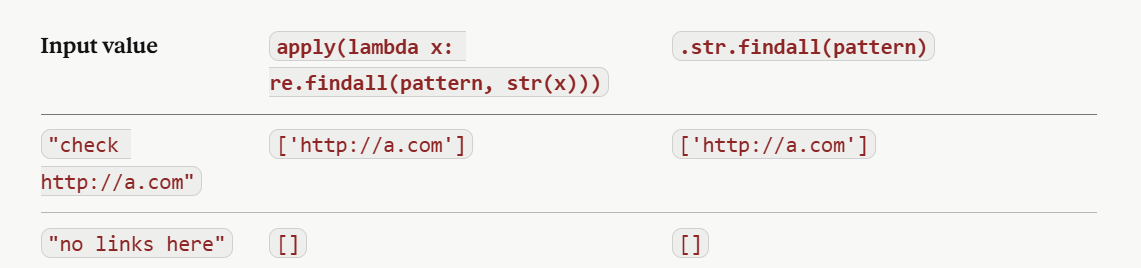

In [378]:
url_patteran= r'(http|https|ftp|ssh)://([\w_-]+(?:(?:\.[\w_-]+)+))([\w.,@?^=%&:/~+#-]*[\w@?^=%&/~+#-])?'

In [379]:
## Remove url
data['urls']=data['reviewText'].apply(lambda x: re.findall(url_patteran,str(x)))

/tmp/ipykernel_3935/758307111.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['urls']=data['reviewText'].apply(lambda x: re.findall(url_patteran,str(x)))


In [380]:
data

,reviewText,rating,special_char,stop_words,urls
0,jace rankin may short nothing mess man hauled ...,1,"[,, ', ,, ., ', ,, ,, ', ., -, ,, ,, ., ,, ', ...","[be, but, he, s, to, with, as, the, who, was, ...",[]
1,great short read want put read one sitting sex...,1,"[., ', ., ., ., ., -, !, !, (, ), !]","[i, didn, t, to, it, down, so, i, it, all, in,...",[]
2,start saying first four books expecting 34 con...,1,"[', ', &, #, ;, &, #, ;, ., ,, ,, ', ,, ., ', ...","[i, ll, by, this, is, the, of, so, i, wasn, t,...",[]
3,aggie angela lansbury carries pocketbooks inst...,1,"[., ,, ., ,, ,, -, ., .]","[is, who, of, them, while, this, is, with, the...",[]
4,expect type book library pleased find price right,1,[],"[i, did, not, this, of, to, be, in, was, to, i...",[]
...,...,...,...,...,...
11995,valentine cupid vampire- jena ian another vamp...,1,"[-, !, -]","[is, a, and, his, there, and, she, is]",[]
11996,read seven books series apocalyptic adventure ...,1,"[., /, ,, ., ., ,, ., ., ., ., ., ,, ,, ., ,, ...","[i, have, all, in, this, is, of, my, this, is,...",[]
11997,book really cuppa situation man capturing woma...,1,"[', ., ', ., ., ', ,, ', .]","[this, just, wasn, t, my, the, of, a, a, in, h...",[]
11998,tried use charge kindle even register charging...,0,"[,, ', ., ., .]","[to, it, to, my, it, didn, t, as, now, i, have...",[]


In [381]:
##So for no Urls available in the dataset. for safer side run the below code to remove it

In [382]:
data['reviewText']=data['reviewText'].apply(lambda x: re.sub(r'(http|https|ftp|ssh)://([\w_-]+(?:(?:\.[\w_-]+)+))([\w.,@?^=%&:/~+#-]*[\w@?^=%&/~+#-])?', '' , str(x)))

/tmp/ipykernel_3935/2014666561.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['reviewText']=data['reviewText'].apply(lambda x: re.sub(r'(http|https|ftp|ssh)://([\w_-]+(?:(?:\.[\w_-]+)+))([\w.,@?^=%&:/~+#-]*[\w@?^=%&/~+#-])?', '' , str(x)))


In [383]:
data.head()

,reviewText,rating,special_char,stop_words,urls
0,jace rankin may short nothing mess man hauled ...,1,"[,, ', ,, ., ', ,, ,, ', ., -, ,, ,, ., ,, ', ...","[be, but, he, s, to, with, as, the, who, was, ...",[]
1,great short read want put read one sitting sex...,1,"[., ', ., ., ., ., -, !, !, (, ), !]","[i, didn, t, to, it, down, so, i, it, all, in,...",[]
2,start saying first four books expecting 34 con...,1,"[', ', &, #, ;, &, #, ;, ., ,, ,, ', ,, ., ', ...","[i, ll, by, this, is, the, of, so, i, wasn, t,...",[]
3,aggie angela lansbury carries pocketbooks inst...,1,"[., ,, ., ,, ,, -, ., .]","[is, who, of, them, while, this, is, with, the...",[]
4,expect type book library pleased find price right,1,[],"[i, did, not, this, of, to, be, in, was, to, i...",[]


In [385]:
data['rating'].value_counts()

,count
rating,
1,8000
0,4000


In [386]:
##Remove Html tags

In [387]:
df['reviewText']=df['reviewText'].apply(lambda x: BeautifulSoup(x, 'lxml').get_text())

In [388]:
data.head()

,reviewText,rating,special_char,stop_words,urls
0,jace rankin may short nothing mess man hauled ...,1,"[,, ', ,, ., ', ,, ,, ', ., -, ,, ,, ., ,, ', ...","[be, but, he, s, to, with, as, the, who, was, ...",[]
1,great short read want put read one sitting sex...,1,"[., ', ., ., ., ., -, !, !, (, ), !]","[i, didn, t, to, it, down, so, i, it, all, in,...",[]
2,start saying first four books expecting 34 con...,1,"[', ', &, #, ;, &, #, ;, ., ,, ,, ', ,, ., ', ...","[i, ll, by, this, is, the, of, so, i, wasn, t,...",[]
3,aggie angela lansbury carries pocketbooks inst...,1,"[., ,, ., ,, ,, -, ., .]","[is, who, of, them, while, this, is, with, the...",[]
4,expect type book library pleased find price right,1,[],"[i, did, not, this, of, to, be, in, was, to, i...",[]


In [389]:
## remove additional spaces
data['reviewText']=data['reviewText'].apply(lambda x: " ".join(x.split()))

/tmp/ipykernel_3935/364750962.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['reviewText']=data['reviewText'].apply(lambda x: " ".join(x.split()))


In [390]:
data.head()

,reviewText,rating,special_char,stop_words,urls
0,jace rankin may short nothing mess man hauled ...,1,"[,, ', ,, ., ', ,, ,, ', ., -, ,, ,, ., ,, ', ...","[be, but, he, s, to, with, as, the, who, was, ...",[]
1,great short read want put read one sitting sex...,1,"[., ', ., ., ., ., -, !, !, (, ), !]","[i, didn, t, to, it, down, so, i, it, all, in,...",[]
2,start saying first four books expecting 34 con...,1,"[', ', &, #, ;, &, #, ;, ., ,, ,, ', ,, ., ', ...","[i, ll, by, this, is, the, of, so, i, wasn, t,...",[]
3,aggie angela lansbury carries pocketbooks inst...,1,"[., ,, ., ,, ,, -, ., .]","[is, who, of, them, while, this, is, with, the...",[]
4,expect type book library pleased find price right,1,[],"[i, did, not, this, of, to, be, in, was, to, i...",[]


In [408]:
data_final= data[['reviewText','rating']]

In [392]:
data_final.head()

,reviewText,rating
0,jace rankin may short nothing mess man hauled ...,1
1,great short read want put read one sitting sex...,1
2,start saying first four books expecting 34 con...,1
3,aggie angela lansbury carries pocketbooks inst...,1
4,expect type book library pleased find price right,1


In [393]:
##Lemmatizer

In [409]:
from nltk.stem import WordNetLemmatizer

In [410]:
lem=WordNetLemmatizer()

In [411]:
def lemmatize_word(text):
  return " ".join([lem.lemmatize(word) for word in text.split()])

In [405]:
import nltk
nltk.download('wordnet')

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [413]:
data_final['reviewText']=data_final['reviewText'].apply(lemmatize_word)

/tmp/ipykernel_3935/951346842.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_final['reviewText']=data_final['reviewText'].apply(lemmatize_word)


In [435]:
data_final.head()

,reviewText,rating
0,jace rankin may short nothing mess man hauled ...,1
1,great short read want put read one sitting sex...,1
2,start saying first four book expecting 34 conc...,1
3,aggie angela lansbury carry pocketbook instead...,1
4,expect type book library pleased find price right,1


In [436]:
##Train Test Split
from sklearn.model_selection import train_test_split

In [437]:
X_train,X_test,Y_train,Y_test=train_test_split(data_final['reviewText'],data_final['rating'],test_size=0.20,random_state=123)

In [438]:
X_train.shape,X_test.shape,Y_train.shape,Y_test.shape

((9600,), (2400,), (9600,), (2400,))

In [439]:
X_train

,reviewText
7098,second book series good first great character ...
6567,loved hooked first page could put read one sit...
3764,enjoyed book ending think author could little ...
2967,gabe much another man touching gabe wanted bre...
4074,first book blurred trilogy part demon age seri...
...,...
7763,started interested one five video tried view w...
5218,good portable copy bible impress thought would...
1346,lena matthew fast becoming one favorite author...
11646,okay read gave book one star based engages emo...


In [440]:
Y_train

,rating
7098,1
6567,1
3764,1
2967,1
4074,1
...,...
7763,0
5218,0
1346,1
11646,0


In [441]:
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer

In [442]:
bow=CountVectorizer()
x_train_bow=bow.fit_transform(X_train).toarray()

In [443]:
x_train_bow

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [444]:
x_test_bow=bow.transform(X_test).toarray()

In [445]:
tfidf=TfidfVectorizer()

In [446]:
x_train_tfidf=tfidf.fit_transform(X_train).toarray()

In [447]:
x_test_tfidf=tfidf.transform(X_test).toarray()

In [448]:
from sklearn.naive_bayes import GaussianNB
nb_model_bow=GaussianNB().fit(x_train_bow,Y_train)
nb_model_tfidf=GaussianNB().fit(x_train_tfidf,Y_train)

In [449]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

In [450]:
y_pred_bow=nb_model_bow.predict(x_test_bow)

In [451]:
y_pred_tfidf=nb_model_tfidf.predict(x_test_tfidf)

In [452]:
confusion_matrix(Y_test,y_pred_bow)

array([[528, 270],
       [757, 845]])

In [453]:
confusion_matrix(Y_test,y_pred_tfidf)

array([[511, 287],
       [740, 862]])

In [458]:
print("BOW accuracy : ",accuracy_score(Y_test,y_pred_bow))

BOW accuracy :  0.5720833333333334


In [459]:
print("TFIDF accuracy : ",accuracy_score(Y_test,y_pred_tfidf))

TFIDF accuracy :  0.5720833333333334
